Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import warnings
import joblib
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
COLORS = ['#5DCAA5', '#534AB7', '#D85A30', '#1D9E75', '#7F77DD', '#F0997B', '#E8C547', '#9B59B6']

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                             classification_report, confusion_matrix,
                             RocCurveDisplay, recall_score, precision_score,
                             PrecisionRecallDisplay)

from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE

DATA_PATH   = r'C:\PROJECTS\Customer Churn Bank\Dataset\analytical_base_table.csv' 
SEED        = 42
TEST_SIZE   = 0.20
CV_FOLDS    = 5

Preporcessing 


In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'Churn rate: {df["churn"].mean():.2%}')
df.head(5)

Shape: (10000, 13)
Churn rate: 20.37%


,credit_score,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_France,country_Germany,country_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,True,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,True,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,True,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,False,True


In [ ]:
X = df.drop('churn', axis=1)
y = df['churn']

print('Feature columns:', X.columns.tolist())
print(f'Class balance — 0: {(y==0).sum()}  1: {(y==1).sum()}')


Feature columns: ['credit_score', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'country_France', 'country_Germany', 'country_Spain']
Class balance — 0: 7963  1: 2037


Train Test Split

In [ ]:
# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)

# Scale numeric columns
NUM_COLS = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']

scaler = StandardScaler()
X_train[NUM_COLS] = scaler.fit_transform(X_train[NUM_COLS])
X_test[NUM_COLS]  = scaler.transform(X_test[NUM_COLS])

# SMOTE on training set only to fix class imbalance
sm = SMOTE(random_state=SEED)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

print(f'Train (after SMOTE): {X_train_bal.shape}')
print(f'class balance: {dict(pd.Series(y_train_bal).value_counts())}')  
print(f'Test: {X_test.shape}')


Train (after SMOTE): (12740, 12)
class balance: {1: np.int64(6370), 0: np.int64(6370)}
Test: (2000, 12)


Models


In [5]:
xgb  = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5,
                     eval_metric='logloss', random_state=SEED)
lgbm = LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31,
                      random_state=SEED, verbose=-1)
cat  = CatBoostClassifier(iterations=300, learning_rate=0.05, depth=6,
                           random_seed=SEED, verbose=0)

models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=SEED),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, max_depth=10, random_state=SEED, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=SEED),  # NEW
    'SVM'                 : SVC(kernel='rbf', probability=True, random_state=SEED),                                             # NEW
    'XGBoost'             : xgb,
    'LightGBM'            : lgbm,
    'CatBoost'            : cat,
    'Voting Ensemble'     : VotingClassifier(
                                estimators=[('xgb', xgb), ('lgbm', lgbm), ('cat', cat)],
                                voting='soft'
                            ),
}
print(f' {len(models)} models ready')

 8 models ready


Training and Evaluation

In [ ]:
cv      = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
results = []

for name, model in models.items():
    print(f'Training {name}...', end=' ')

    cv_res = cross_validate(
        model, X_train_bal, y_train_bal, cv=cv,
        scoring=['roc_auc', 'f1', 'precision', 'recall'], n_jobs=-1
    )

    model.fit(X_train_bal, y_train_bal)
    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        'Model'          : name,
        'CV ROC-AUC'     : cv_res['test_roc_auc'].mean(),
        'CV F1'          : cv_res['test_f1'].mean(),
        'CV Precision'   : cv_res['test_precision'].mean(),   
        'CV Recall'      : cv_res['test_recall'].mean(),      
        'Test ROC-AUC'   : roc_auc_score(y_test, y_pred_prob),
        'Test F1'        : f1_score(y_test, y_pred),
        'Test Precision' : precision_score(y_test, y_pred),  
        'Test Recall'    : recall_score(y_test, y_pred),     
        'Test Accuracy'  : accuracy_score(y_test, y_pred),
    })
    print(f"ROC-AUC {results[-1]['Test ROC-AUC']:.4f}  |  F1 {results[-1]['Test F1']:.4f}")

Training Logistic Regression... ROC-AUC 0.7689  |  F1 0.4967
Training Random Forest... ROC-AUC 0.8601  |  F1 0.6066
Training Gradient Boosting... ROC-AUC 0.8713  |  F1 0.6255
Training SVM... ROC-AUC 0.8492  |  F1 0.5965
Training XGBoost... ROC-AUC 0.8637  |  F1 0.6206
Training LightGBM... ROC-AUC 0.8581  |  F1 0.6109
Training CatBoost... ROC-AUC 0.8703  |  F1 0.6299
Training Voting Ensemble... ROC-AUC 0.8677  |  F1 0.6299


In [7]:
results_df = pd.DataFrame(results).sort_values('Test ROC-AUC', ascending=False).reset_index(drop=True)
print('\n── Leaderboard ──')
results_df.style.background_gradient(
    cmap='Greens',
    subset=['Test ROC-AUC', 'Test F1', 'Test Precision', 'Test Recall', 'Test Accuracy']
).format(precision=4)


── Leaderboard ──


,Model,CV ROC-AUC,CV F1,CV Precision,CV Recall,Test ROC-AUC,Test F1,Test Precision,Test Recall,Test Accuracy
0,Gradient Boosting,0.9509,0.8801,0.8971,0.8637,0.8713,0.6255,0.6172,0.6339,0.8455
1,CatBoost,0.9605,0.8939,0.9184,0.8708,0.8703,0.6299,0.6761,0.5897,0.8590
2,Voting Ensemble,0.9628,0.8988,0.9187,0.8799,0.8677,0.6299,0.6761,0.5897,0.8590
3,XGBoost,0.9545,0.8847,0.9029,0.8672,0.8637,0.6206,0.6350,0.6069,0.8490
4,Random Forest,0.9308,0.8476,0.8623,0.8334,0.8601,0.6066,0.5487,0.6781,0.8210
5,LightGBM,0.9647,0.9035,0.9252,0.8829,0.8581,0.6109,0.6647,0.5651,0.8535
6,SVM,0.9043,0.8277,0.8256,0.8298,0.8492,0.5965,0.5105,0.7174,0.8025
7,Logistic Regression,0.8144,0.7353,0.7392,0.7316,0.7689,0.4967,0.3997,0.6560,0.7295


Visualization


In [ ]:
import os
os.makedirs('plots', exist_ok=True)

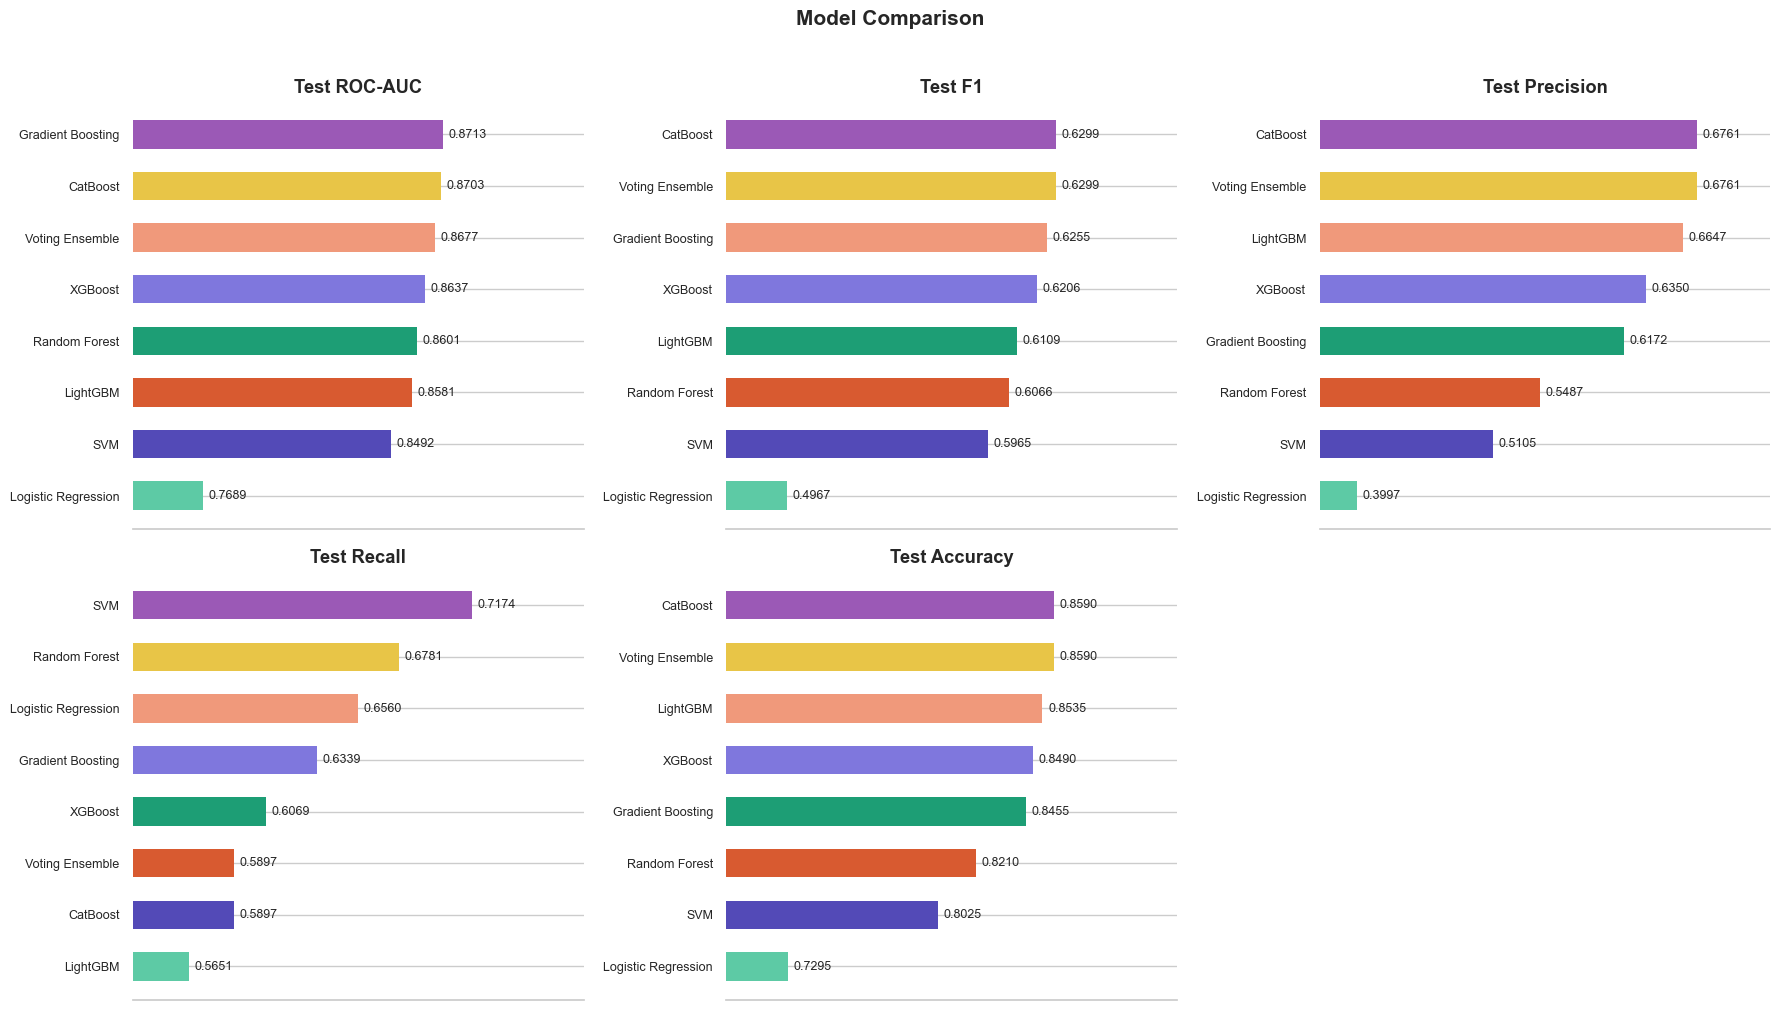

In [ ]:
#Model Comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics   = ['Test ROC-AUC', 'Test F1', 'Test Precision', 'Test Recall', 'Test Accuracy']
axes_flat = axes.flatten()
axes_flat[-1].set_visible(False)  

for ax, metric in zip(axes_flat, metrics):
    sorted_df = results_df.sort_values(metric)
    bars = ax.barh(sorted_df['Model'], sorted_df[metric],
                   color=COLORS[:len(sorted_df)], edgecolor='none', height=0.55)
    ax.bar_label(bars, fmt='%.4f', padding=4, fontsize=9)
    ax.set_title(metric, fontweight='bold')
    ax.set_xlim(sorted_df[metric].min() - 0.03, sorted_df[metric].max() + 0.06)
    ax.tick_params(axis='y', labelsize=9)
    ax.set_xlabel('')
    sns.despine(ax=ax, left=True, bottom=False)
    ax.xaxis.set_visible(False)

fig.suptitle('Model Comparison', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plots/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


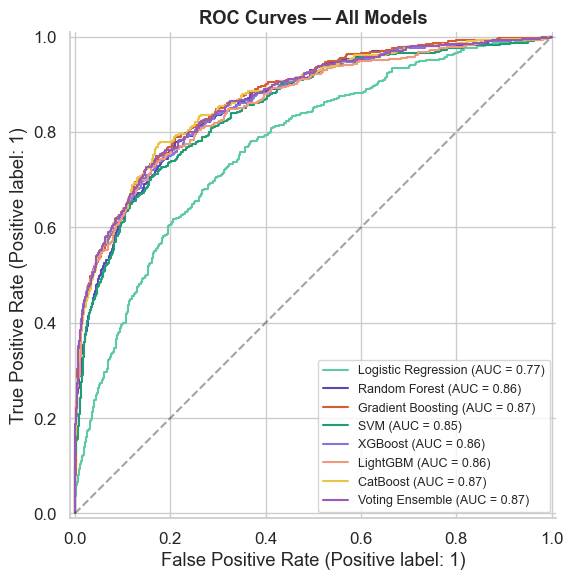

In [ ]:
#ROC Curves for All Models
fig, ax = plt.subplots(figsize=(8, 6))

for (name, model), color in zip(models.items(), COLORS):
    y_prob = model.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax, name=name, color=color)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_title('ROC Curves — All Models', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig('plots/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

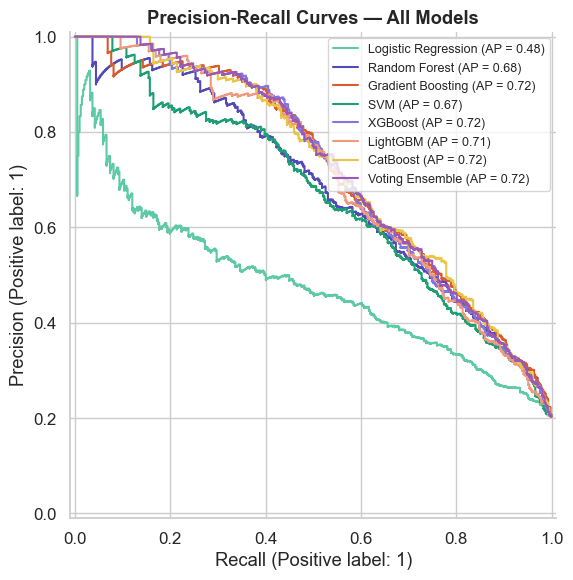

In [11]:
# Precision-Recall Curves for all models
fig, ax = plt.subplots(figsize=(8, 6))

for (name, model), color in zip(models.items(), COLORS):
    y_prob = model.predict_proba(X_test)[:, 1]
    PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=ax, name=name, color=color)

ax.set_title('Precision-Recall Curves — All Models', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig('plots/Precision-Recall_Curves.png', dpi=150, bbox_inches='tight')
plt.show()


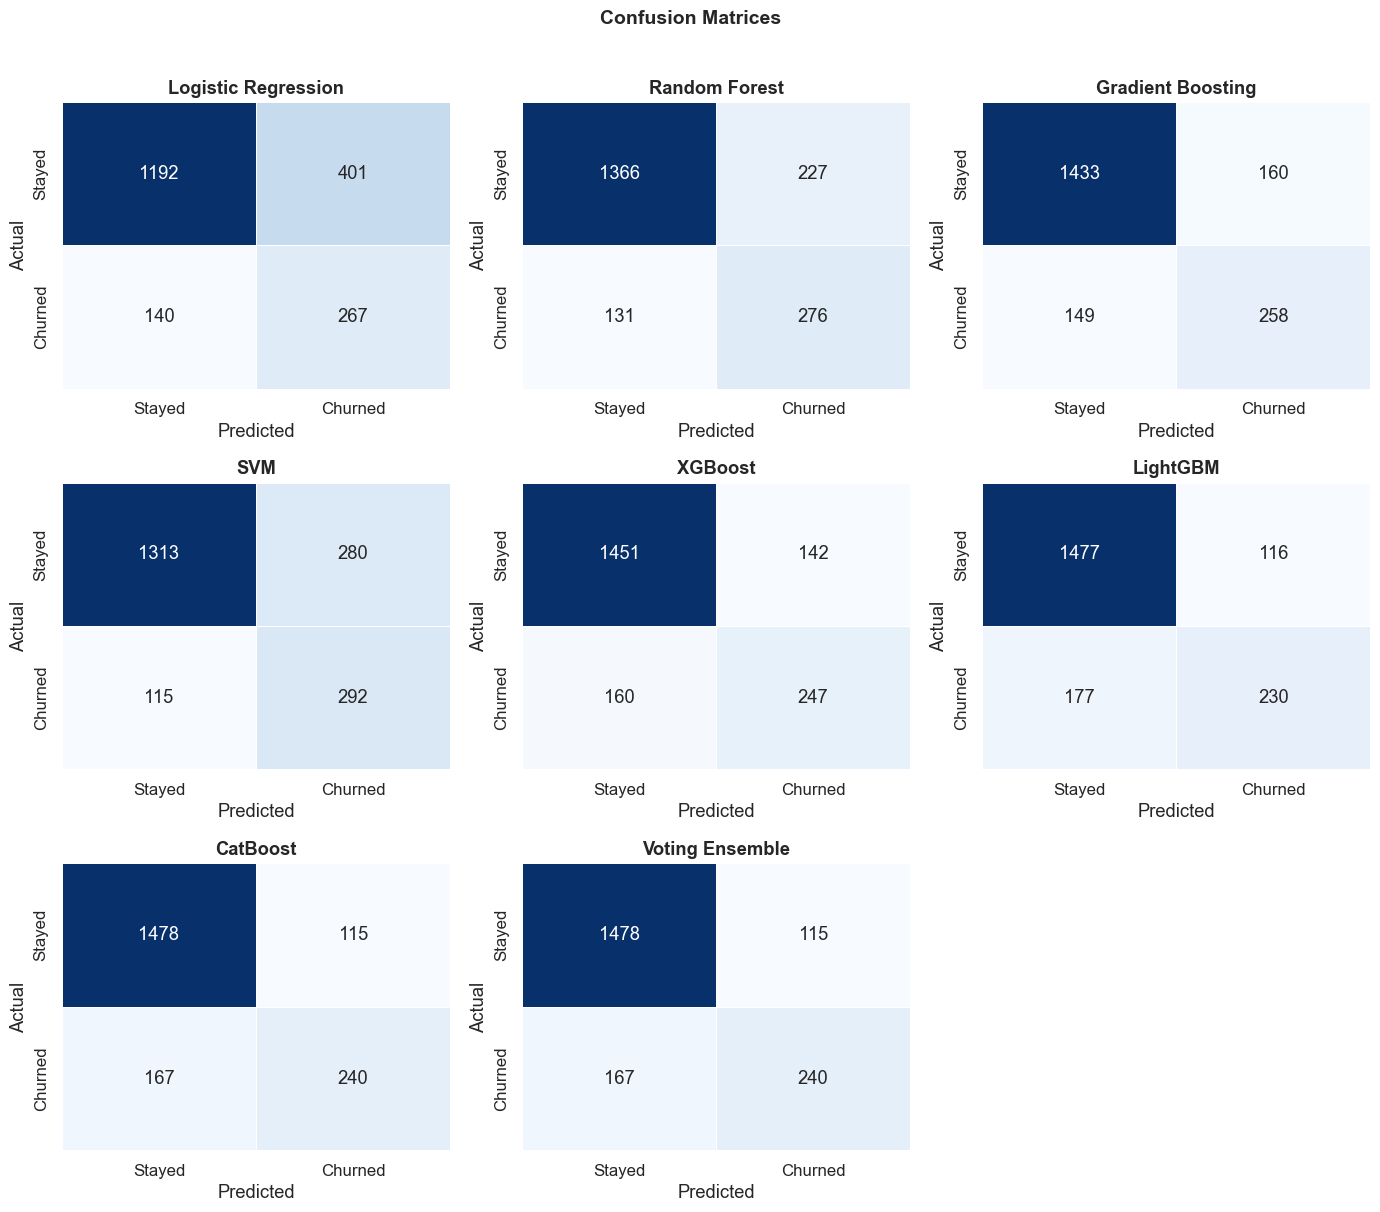

In [ ]:
#confusion Matrices
n = len(models)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 4))
axes_flat = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_flat[idx],
                xticklabels=['Stayed', 'Churned'],
                yticklabels=['Stayed', 'Churned'],
                linewidths=0.5, cbar=False)
    axes_flat[idx].set_title(name, fontweight='bold')
    axes_flat[idx].set_xlabel('Predicted')
    axes_flat[idx].set_ylabel('Actual')

# Hide empty subplots
for ax in axes_flat[n:]:
    ax.set_visible(False)

fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plots/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

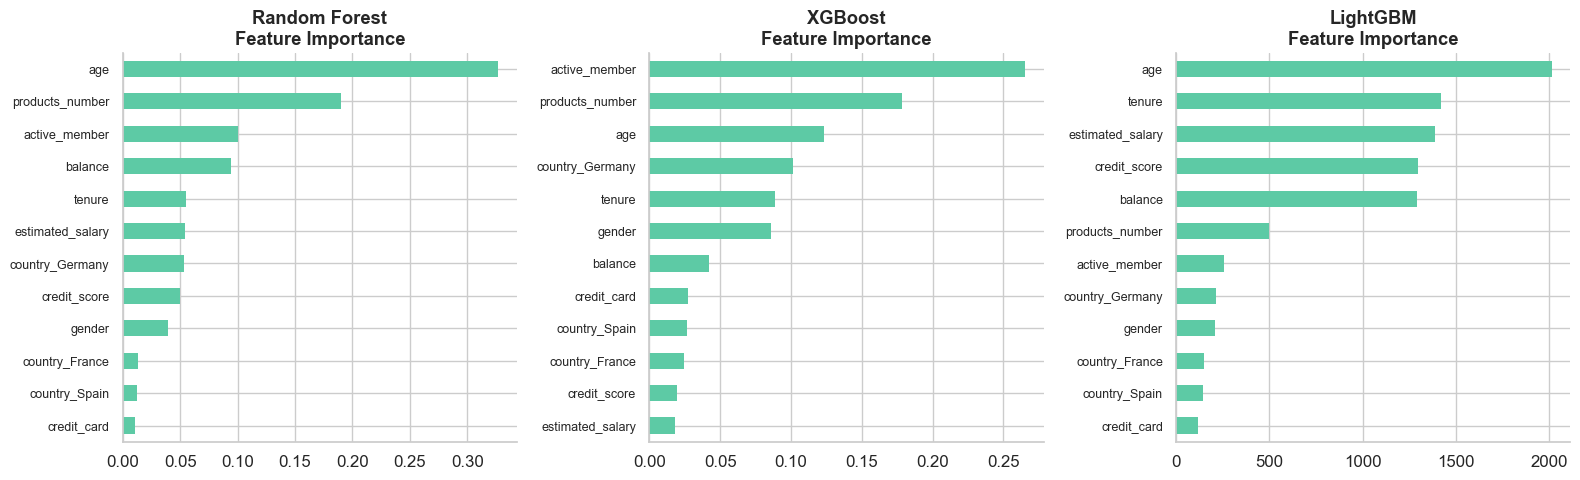

In [13]:
# Feature importance from tree-based models
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
tree_models = ['Random Forest', 'XGBoost', 'LightGBM']

for ax, name in zip(axes, tree_models):
    model  = models[name]
    imps   = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)
    imps.plot(kind='barh', ax=ax, color='#5DCAA5', edgecolor='none')
    ax.set_title(f'{name}\nFeature Importance', fontweight='bold')
    ax.tick_params(axis='y', labelsize=9)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('plots/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

Saving Models

In [14]:
MODEL_DIR = r'C:\PROJECTS\Customer Churn Bank\model'   
os.makedirs(MODEL_DIR, exist_ok=True)

auto_select = True                 
if auto_select:
    BEST_MODEL_NAME = results_df.iloc[0]['Model']

best_model = models[BEST_MODEL_NAME]

joblib.dump(best_model,           os.path.join(MODEL_DIR, 'churn_model.pkl'))
joblib.dump(scaler,               os.path.join(MODEL_DIR, 'scaler.pkl'))
joblib.dump(X.columns.tolist(),   os.path.join(MODEL_DIR, 'feature_columns.pkl'))

print(f'Best model : {BEST_MODEL_NAME}')
print(f' Test ROC-AUC : {results_df[results_df["Model"]==BEST_MODEL_NAME]["Test ROC-AUC"].values[0]:.4f}')
print(f'Test F1 : {results_df[results_df["Model"]==BEST_MODEL_NAME]["Test F1"].values[0]:.4f}')
print()
print(f'Saved: {os.path.join(MODEL_DIR, "churn_model.pkl")}')
print(f'Saved: {os.path.join(MODEL_DIR, "scaler.pkl")}')
print(f'Saved: {os.path.join(MODEL_DIR, "feature_columns.pkl")}')
print(f'Saved: {os.path.join(MODEL_DIR, "label_encoders.pkl")}')
print()
print('── Full classification report ──')
print(classification_report(y_test, best_model.predict(X_test), target_names=['Stayed', 'Churned']))

Best model : Gradient Boosting
 Test ROC-AUC : 0.8713
Test F1 : 0.6255

Saved: C:\PROJECTS\Customer Churn Bank\model\churn_model.pkl
Saved: C:\PROJECTS\Customer Churn Bank\model\scaler.pkl
Saved: C:\PROJECTS\Customer Churn Bank\model\feature_columns.pkl
Saved: C:\PROJECTS\Customer Churn Bank\model\label_encoders.pkl

── Full classification report ──
              precision    recall  f1-score   support

      Stayed       0.91      0.90      0.90      1593
     Churned       0.62      0.63      0.63       407

    accuracy                           0.85      2000
   macro avg       0.76      0.77      0.76      2000
weighted avg       0.85      0.85      0.85      2000

